In [ ]:
import numpy as np # import numpy library and give it an alias 'np'
import pandas as pd
import matplotlib.pyplot as plt #pyplot is as submodule of matplotlib, used for plotting graphs, and we give it an alias 'plt'

In [ ]:
df=pd.read_csv('Salary_Data.csv') # the csv file is loaded into a table like structure called dataframe and stored in the variable df
# index, YearsExperience, Salary are the columns of the dataframe {index is added for free by pandas}
X=df["YearsExperience"].values
# df["YearsExperience"] gives us the column of the dataframe with the name "YearsExperience" and .values gives us the values of that column as a numpy array
Y=df["Salary"].values

In [9]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [10]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

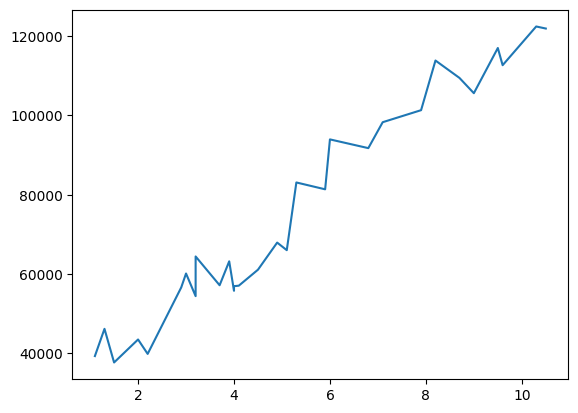

In [11]:
plt.plot(X,Y)

Normalizing dataset

In [ ]:
#X=np.array(X) - not needed because X is already a numpy array due to the .values attribute used while extracting the column from the dataframe
#Y=np.array(Y)

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

In [14]:
def mean(X):
    return np.sum(X)/len(X)

In [15]:
def variance(X):
    mean_value=mean(X)
    return np.sum((X-mean_value)**2)/len(X)

In [16]:
def norm(X):
    mean_value=mean(X)
    variance_value=variance(X)
    return (X-mean_value)/np.sqrt(variance_value)

In [17]:
X_norm=norm(X)

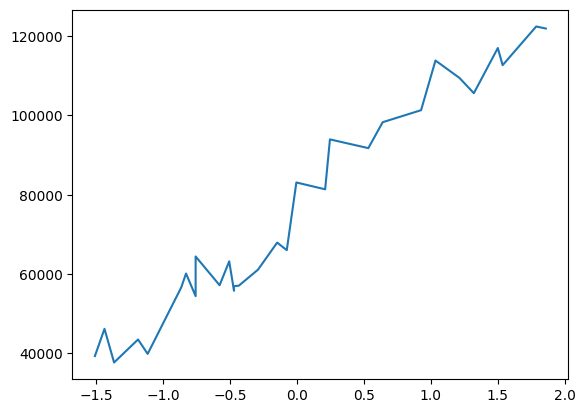

In [18]:
plt.plot(X_norm, Y)

In [19]:
import random

In [ ]:
class SimpleLR:
    def __init__(self, lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr=lr  # an attribute named lr is created inside this object for learning rate
        self.max_iter=max_iter
        self.threshold=threshold
        self.weight = random.uniform(-1,1)
        self.bias=random.uniform(-1,1)
    
    def predict(self, X):
        return self.weight*X + self.bias

    def fit(self, X, Y):
        n=len(X)
        loss_history=[]
        y_pred = self.predict(X)
        errors=Y-y_pred 
        prev_loss = 1/(2*n)*np.sum(errors**2) # 2 is added in the denominator to make the derivative simpler, it does not affect the optimization process
        loss_history.append(prev_loss)

        for i in range(self.max_iter):
            w_grad= (1/n) * np.sum(errors * X) # calculate. u will get this. the ans is actually negative
            b_grad= (1/n) * np.sum(errors) # calculate. u will get this. the ans is actually negative
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors=Y-y_pred
            curr_loss = 1/(2*n)*np.sum(errors**2)
            loss_history.append(curr_loss)
            if abs(curr_loss-prev_loss) < self.threshold:
                break
            prev_loss=curr_loss
        return loss_history
    
    def plot(self, X, Y):
        y_pred = self.predict(X)
        plt.plot(X, Y)
        plt.plot(X, y_pred)

In [32]:
model = SimpleLR()

In [33]:
loss_history = model.fit(X_norm, Y)

In [34]:
loss_history

[np.float64(3251543436.252223),
 np.float64(2636720923.7779174),
 np.float64(2138714688.67373),
 np.float64(1735329638.239338),
 np.float64(1408587747.3874805),
 np.float64(1143926815.7974756),
 np.float64(929551461.2095723),
 np.float64(755907423.9933702),
 np.float64(615255753.8482466),
 np.float64(501327901.0306964),
 np.float64(409046340.2484806),
 np.float64(334298276.0148862),
 np.float64(273752343.98567456),
 np.float64(224710139.04201308),
 np.float64(184985953.0376473),
 np.float64(152809362.37411106),
 np.float64(126746323.93664658),
 np.float64(105635262.80230045),
 np.float64(88535303.28348008),
 np.float64(74684336.0732355),
 np.float64(63465052.63293752),
 np.float64(54377433.04629608),
 np.float64(47016461.181116514),
 np.float64(41054073.97032105),
 np.float64(36224540.32957679),
 np.float64(32312618.080573864),
 np.float64(29143961.05888148),
 np.float64(26577348.871310703),
 np.float64(24498392.999378394),
 np.float64(22814438.74311318),
 np.float64(21450435.795538366

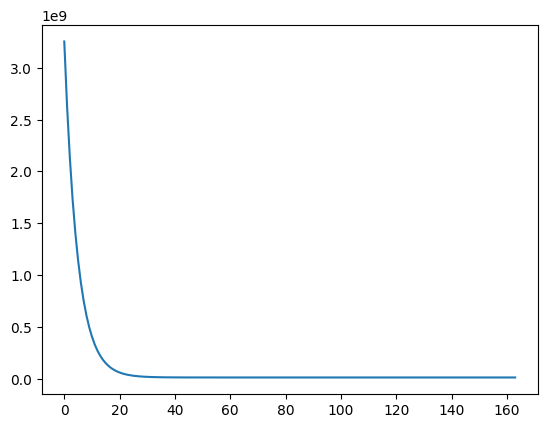

In [35]:
plt.plot(loss_history)

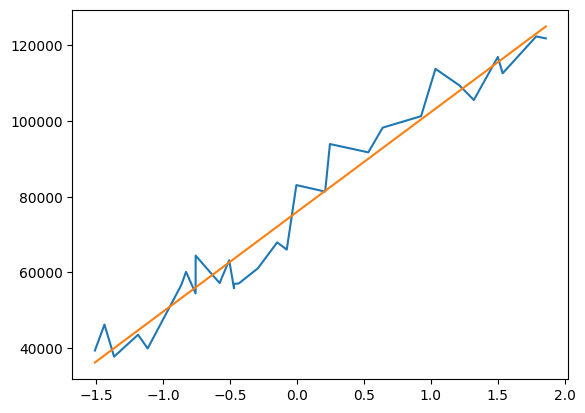

In [36]:
model.plot(X_norm, Y)